In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# ***Initialization***

In [ ]:
# Importing some library files...
import sklearn
import pandas as pd
import numpy as np
import string
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from pandas.core.dtypes.common import is_numeric_dtype
import pickle
from google.colab import files
import random
import warnings as wr
wr.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sb
from sklearn import tree

import seaborn as sns

default_fig_size_inch = 20

In [ ]:
# Fetching the Dataset for training...
path = "/content/drive/MyDrive/button-ordering-collab/raw_dataset.csv"
df = pd.read_csv(path)
target = 'button_rank'
print(len(df))
df.head()

63


,web_id,button_id,button_width,button_width_ratio_with_largest_button_width,button_width_ratio_with_smallest_button_width,button_height,button_height_ratio_with_largest_button_height,button_height_ratio_with_smallest_button_height,button_color_R,button_color_G,...,button_text_is_italic,total_number_of_buttons_in_the_website,total_number_of_buttons_in_the_navbar,largest_button_text_in_the_website,smallest_button_text_in_the_website,largest_button_width_in_the_website,smallest_button_width_in_the_website,largest_button_height_in_the_website,smallest_button_height_in_the_website,button_rank
0,1.0,1.0,0.025000,0.24,1.20,0.022851,0.21,1.000000,1.0,1.000000,...,0.0,6.0,0.166667,30.0,10.0,200.0,40.0,100.0,21.0,0.666667
1,1.0,2.0,0.104167,1.00,5.00,0.108814,1.00,4.761905,1.0,0.894118,...,0.0,6.0,0.166667,30.0,10.0,200.0,40.0,100.0,21.0,0.933333
2,1.0,3.0,0.052083,0.50,2.50,0.081610,0.75,3.571429,1.0,0.894118,...,0.0,6.0,0.166667,30.0,10.0,200.0,40.0,100.0,21.0,0.733333
3,1.0,4.0,0.026042,0.25,1.25,0.065288,0.60,2.857143,1.0,0.894118,...,0.0,6.0,0.166667,30.0,10.0,200.0,40.0,100.0,21.0,0.566667
4,1.0,5.0,0.020833,0.20,1.00,0.027203,0.25,1.190476,1.0,0.894118,...,1.0,6.0,0.166667,30.0,10.0,200.0,40.0,100.0,21.0,0.366667


# ***Dataset Preprocessing***

***Dataset Cleaning***

In [ ]:
print(len(df))
df = df.dropna()
print(len(df))
df = df.drop(["web_id", "button_id"], axis=1)
df.head()

63
63


,button_width,button_width_ratio_with_largest_button_width,button_width_ratio_with_smallest_button_width,button_height,button_height_ratio_with_largest_button_height,button_height_ratio_with_smallest_button_height,button_color_R,button_color_G,button_color_B,button_color_A,...,button_text_is_italic,total_number_of_buttons_in_the_website,total_number_of_buttons_in_the_navbar,largest_button_text_in_the_website,smallest_button_text_in_the_website,largest_button_width_in_the_website,smallest_button_width_in_the_website,largest_button_height_in_the_website,smallest_button_height_in_the_website,button_rank
0,0.025000,0.24,1.20,0.022851,0.21,1.000000,1.0,1.000000,1.000000,1.0,...,0.0,6.0,0.166667,30.0,10.0,200.0,40.0,100.0,21.0,0.666667
1,0.104167,1.00,5.00,0.108814,1.00,4.761905,1.0,0.894118,0.768627,1.0,...,0.0,6.0,0.166667,30.0,10.0,200.0,40.0,100.0,21.0,0.933333
2,0.052083,0.50,2.50,0.081610,0.75,3.571429,1.0,0.894118,0.768627,1.0,...,0.0,6.0,0.166667,30.0,10.0,200.0,40.0,100.0,21.0,0.733333
3,0.026042,0.25,1.25,0.065288,0.60,2.857143,1.0,0.894118,0.768627,1.0,...,0.0,6.0,0.166667,30.0,10.0,200.0,40.0,100.0,21.0,0.566667
4,0.020833,0.20,1.00,0.027203,0.25,1.190476,1.0,0.894118,0.768627,1.0,...,1.0,6.0,0.166667,30.0,10.0,200.0,40.0,100.0,21.0,0.366667


In [ ]:
# df.describe()
df.dtypes

button_width                                                   float64
button_width_ratio_with_largest_button_width                   float64
button_width_ratio_with_smallest_button_width                  float64
button_height                                                  float64
button_height_ratio_with_largest_button_height                 float64
button_height_ratio_with_smallest_button_height                float64
button_color_R                                                 float64
button_color_G                                                 float64
button_color_B                                                 float64
button_color_A                                                 float64
button_contrast_with_background                                float64
button_center_x_coordinate                                     float64
button_center_y_coordinate                                     float64
button_is_on_navbar                                            float64
button

***Synthetic Date Generation***

In [ ]:
# def add_random_noise(df, noise_level=0.1):
#     noise = np.random.normal(scale=noise_level * df.std(), size=df.shape)
#     noisy_df = df + noise
#     noise
#     return noise

# noise = add_random_noise(df)
# noisy_df = df + noise

# print("Original DataFrame:")
# print(df.head())
# print("\nNoisy DataFrame:")
# print(noisy_df.head())

In [ ]:
# !pip install git+https://github.com/nickkunz/smogn.git

In [ ]:
# import smogn
# df_smogn = smogn.smoter(data = noisy_df, y = target)
# print(len(df))
# print(len(df_smogn))

***Feature Engineering***

In [ ]:
features = ["button_width",
"button_width_ratio_with_largest_button_width",
"button_width_ratio_with_smallest_button_width",
"button_height",
"button_height_ratio_with_largest_button_height",
"button_height_ratio_with_smallest_button_height",
"button_color_R",
"button_color_G",
"button_color_B",
"button_color_A",
"button_contrast_with_background",
"button_center_x_coordinate",
"button_center_y_coordinate",
"button_is_on_navbar",
"button_is_on_footer",
"button_is_on_left_half_of_screen",
"button_is_on_right_half_of_screen",
"button_is_on_upper_half_of_screen",
"button_is_on_lower_half_of_screen",
"button_is_on_horizontal_center_of_screen",
"button_is_on_vertical_center_of_screen",
"total_number_of_buttons_in_radius_5_percent_of_screen_size",
"total_number_of_buttons_in_radius_10_percent_of_screen_size",
"total_number_of_buttons_in_radius_25_percent_of_screen_size",
"total_number_of_buttons_in_radius_50_percent_of_screen_size",
"button_text_size",
"button_text_size_ratio_with_largest_button_text",
"button_text_size_ratio_with_smallest_button_text",
"button_text_color_R",
"button_text_color_G",
"button_text_color_B",
"button_text_color_A",
"button_text_contrast_with_button",
"button_text_is_bold",
"button_text_is_italic",
"total_number_of_buttons_in_the_website",
"total_number_of_buttons_in_the_navbar",
"largest_button_text_in_the_website",
"smallest_button_text_in_the_website",
"largest_button_width_in_the_website",
"smallest_button_width_in_the_website",
"largest_button_height_in_the_website",
"smallest_button_height_in_the_website"]

normalize_these = ["button_width_ratio_with_smallest_button_width",
"button_height_ratio_with_smallest_button_height",
"button_text_size",
"button_text_size_ratio_with_smallest_button_text",
"total_number_of_buttons_in_the_website",
"largest_button_text_in_the_website",
"smallest_button_text_in_the_website",
"largest_button_width_in_the_website",
"smallest_button_width_in_the_website",
"largest_button_height_in_the_website",
"smallest_button_height_in_the_website"]

features_orig = features
df_orig = df

In [ ]:
# from sklearn.preprocessing import MinMaxScaler

# # Sample data (replace with your actual data)
# data = df

# # Define columns to skip scaling
# skip_cols = normalize_these

# # Separate data
# data_to_scale = data[skip_cols]
# data_skipped = data[data.columns.difference(skip_cols)]

# # Apply MinMaxScaler
# scaler = MinMaxScaler()
# scaled_data = scaler.fit_transform(data_to_scale)

# # Combine dataframes
# combined_data = pd.concat([pd.DataFrame(scaled_data, columns=data_to_scale.columns), data_skipped], axis=1)

# combined_data

In [ ]:
# df

In [ ]:
# from sklearn.preprocessing import MinMaxScaler

# scaler = MinMaxScaler()
# scaled_data = scaler.fit_transform(df)
# df = pd.DataFrame(scaled_data, columns=df.columns)
# df

In [ ]:
# df.drop(target, axis=1).columns == features

In [ ]:
# temp = combined_data.columns.difference([target])
# features = temp
# df = combined_data

In [ ]:
# Define Gini index function
def gini_index(feature):
    # Get unique values in feature
    values = df[feature].unique()
    # Calculate proportion of each value
    proportions = []
    for value in values:
        proportion = len(df[df[feature] == value]) / len(df)
        proportions.append(proportion)
    # Calculate Gini index
    gini = 1 - sum([p**2 for p in proportions])
    return gini

gini_scores = {}
for feature in features:
    gini_scores[feature] = gini_index(feature)

# Initialize List with feature names with Gini value 0
features_to_drop = []

gini_scores_reverse = {}

for feature, gini_score in sorted(gini_scores.items(), key=lambda x: x[1], reverse=True):
  gini_scores_reverse[gini_score] = []

for feature, gini_score in gini_scores.items():
  gini_scores_reverse[gini_score].append(feature)

print("Gini Score"," : ","Feature Names")
for gini_score, feature_names in gini_scores_reverse.items():
  print(gini_score," : ", end = ""), print(*feature_names, sep = ", ")

Gini Score  :  Feature Names
0.9735449735449736  : button_width
0.9715293524817334  : button_text_contrast_with_button
0.9690098261526833  : button_contrast_with_background
0.9674981103552532  : button_center_y_coordinate
0.9538926681783825  : button_color_G
0.9478458049886621  : button_color_B
0.9438145628621819  : button_center_x_coordinate
0.9352481733434115  : button_height
0.9211388259007305  : button_width_ratio_with_largest_button_width
0.9201310153691105  : button_width_ratio_with_smallest_button_width
0.8984630889392794  : button_color_R
0.8959435626102293  : largest_button_width_in_the_website, smallest_button_width_in_the_website, largest_button_height_in_the_website
0.8626858150667674  : smallest_button_height_in_the_website
0.8591584782060973  : button_height_ratio_with_largest_button_height
0.8586545729402872  : total_number_of_buttons_in_radius_25_percent_of_screen_size
0.8238851095993953  : total_number_of_buttons_in_radius_50_percent_of_screen_size
0.7891156462585034  

In [ ]:
# Choosing one feature among many with same gini

for gini_score, feature_names in gini_scores_reverse.items():
  if gini_score == 0:
    unselected_features = feature_names
  else:
    selected_feature = random.choice(feature_names)
    unselected_features = [feature for feature in feature_names if feature != selected_feature]
  if len(unselected_features):
    print(*unselected_features, sep=",")
  features_to_drop.extend(unselected_features)

smallest_button_width_in_the_website,largest_button_height_in_the_website
button_text_color_G
button_is_on_lower_half_of_screen
button_text_is_bold
button_text_color_A


In [ ]:
# Drop columns in 'gini_scores'
for feature in features_to_drop:
  del gini_scores[feature]

# Drop columns in 'skills' array
print(len(features))
features = [feature for feature in features if feature not in features_to_drop]
print(len(features))

# Drop columns in 'df' dataframe
df.drop(columns=features_to_drop, inplace=True)
df.tail()

43
37


,button_width,button_width_ratio_with_largest_button_width,button_width_ratio_with_smallest_button_width,button_height,button_height_ratio_with_largest_button_height,button_height_ratio_with_smallest_button_height,button_color_R,button_color_G,button_color_B,button_color_A,...,button_text_color_B,button_text_contrast_with_button,button_text_is_italic,total_number_of_buttons_in_the_website,total_number_of_buttons_in_the_navbar,largest_button_text_in_the_website,smallest_button_text_in_the_website,largest_button_width_in_the_website,smallest_button_height_in_the_website,button_rank
58,0.075972,0.710744,1.343750,0.039440,0.885714,1.000000,0.298039,0.686275,0.313725,1.0,...,1.0,0.079765,0.0,7.0,0.0,13.0,13.0,121.0,31.0,0.485714
59,0.068021,0.636364,1.203125,0.039440,0.885714,1.000000,0.298039,0.686275,0.313725,1.0,...,1.0,0.079765,0.0,7.0,0.0,13.0,13.0,121.0,31.0,0.342857
60,0.106890,1.000000,1.890625,0.044529,1.000000,1.129032,0.000000,0.482353,1.000000,1.0,...,1.0,0.107025,0.0,7.0,0.0,13.0,13.0,121.0,31.0,0.942857
61,0.095406,0.892562,1.687500,0.044529,1.000000,1.129032,0.862745,0.207843,0.270588,1.0,...,1.0,0.124500,0.0,7.0,0.0,13.0,13.0,121.0,31.0,0.914286
62,0.080389,0.752066,1.421875,0.039440,0.885714,1.000000,1.000000,0.756863,0.027451,1.0,...,1.0,0.062043,0.0,7.0,0.0,13.0,13.0,121.0,31.0,0.257143


***Train Test Split***

In [ ]:
y = df[target]
X = df.drop(target, axis=1)
X.describe()

,button_width,button_width_ratio_with_largest_button_width,button_width_ratio_with_smallest_button_width,button_height,button_height_ratio_with_largest_button_height,button_height_ratio_with_smallest_button_height,button_color_R,button_color_G,button_color_B,button_color_A,...,button_text_color_R,button_text_color_B,button_text_contrast_with_button,button_text_is_italic,total_number_of_buttons_in_the_website,total_number_of_buttons_in_the_navbar,largest_button_text_in_the_website,smallest_button_text_in_the_website,largest_button_width_in_the_website,smallest_button_height_in_the_website
count,63.000000,63.000000,63.000000,63.000000,63.000000,63.000000,63.000000,63.000000,63.000000,63.000000,...,63.000000,63.000000,63.000000,63.000000,63.000000,63.000000,63.000000,63.000000,63.000000,63.000000
mean,0.134329,0.717559,1.478714,0.051859,0.748924,1.483219,0.595892,0.556365,0.441768,0.988841,...,0.744600,0.715531,0.244235,0.031746,6.555556,0.015873,18.190476,14.063492,186.238095,33.857143
std,0.166112,0.241474,0.661022,0.024468,0.276404,0.924141,0.387519,0.277695,0.337641,0.052129,...,0.428776,0.442540,0.295004,0.176731,1.292382,0.049317,5.060464,2.354632,139.822204,10.089690
min,0.020833,0.200000,1.000000,0.022851,0.210000,1.000000,0.000000,0.000000,0.000000,0.663000,...,0.000000,0.000000,0.051135,0.000000,4.000000,0.000000,13.000000,10.000000,97.000000,21.000000
25%,0.053503,0.523303,1.005102,0.039440,0.512195,1.000000,0.227451,0.362745,0.164706,1.000000,...,0.405882,0.064706,0.077774,0.000000,6.000000,0.000000,13.000000,13.000000,117.000000,26.000000
50%,0.078288,0.752212,1.250000,0.046892,0.883721,1.039216,0.752941,0.596078,0.372549,1.000000,...,1.000000,1.000000,0.104085,0.000000,6.000000,0.000000,18.000000,13.000000,127.000000,34.000000
75%,0.118998,0.991803,1.763889,0.056707,1.000000,1.461538,0.998039,0.754902,0.788235,1.000000,...,1.000000,1.000000,0.221815,0.000000,7.000000,0.000000,20.000000,16.000000,192.000000,38.000000
max,0.626305,1.000000,5.000000,0.131665,1.000000,4.761905,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,9.000000,0.166667,30.000000,18.000000,600.000000,51.000000


In [ ]:
# Splitting Data into Train and Test Sets...
SEED = 42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=SEED)

In [ ]:
X_test2 = X_test[:1]
X_test2

,button_width,button_width_ratio_with_largest_button_width,button_width_ratio_with_smallest_button_width,button_height,button_height_ratio_with_largest_button_height,button_height_ratio_with_smallest_button_height,button_color_R,button_color_G,button_color_B,button_color_A,...,button_text_color_R,button_text_color_B,button_text_contrast_with_button,button_text_is_italic,total_number_of_buttons_in_the_website,total_number_of_buttons_in_the_navbar,largest_button_text_in_the_website,smallest_button_text_in_the_website,largest_button_width_in_the_website,smallest_button_height_in_the_website
61,0.095406,0.892562,1.6875,0.044529,1.0,1.129032,0.862745,0.207843,0.270588,1.0,...,1.0,1.0,0.1245,0.0,7.0,0.0,13.0,13.0,121.0,31.0


In [ ]:
y_orig = df_orig[target]
X_orig = df_orig.drop(target, axis=1)
X_orig.describe()

,button_width,button_width_ratio_with_largest_button_width,button_width_ratio_with_smallest_button_width,button_height,button_height_ratio_with_largest_button_height,button_height_ratio_with_smallest_button_height,button_color_R,button_color_G,button_color_B,button_color_A,...,button_text_color_R,button_text_color_B,button_text_contrast_with_button,button_text_is_italic,total_number_of_buttons_in_the_website,total_number_of_buttons_in_the_navbar,largest_button_text_in_the_website,smallest_button_text_in_the_website,largest_button_width_in_the_website,smallest_button_height_in_the_website
count,63.000000,63.000000,63.000000,63.000000,63.000000,63.000000,63.000000,63.000000,63.000000,63.000000,...,63.000000,63.000000,63.000000,63.000000,63.000000,63.000000,63.000000,63.000000,63.000000,63.000000
mean,0.134329,0.717559,1.478714,0.051859,0.748924,1.483219,0.595892,0.556365,0.441768,0.988841,...,0.744600,0.715531,0.244235,0.031746,6.555556,0.015873,18.190476,14.063492,186.238095,33.857143
std,0.166112,0.241474,0.661022,0.024468,0.276404,0.924141,0.387519,0.277695,0.337641,0.052129,...,0.428776,0.442540,0.295004,0.176731,1.292382,0.049317,5.060464,2.354632,139.822204,10.089690
min,0.020833,0.200000,1.000000,0.022851,0.210000,1.000000,0.000000,0.000000,0.000000,0.663000,...,0.000000,0.000000,0.051135,0.000000,4.000000,0.000000,13.000000,10.000000,97.000000,21.000000
25%,0.053503,0.523303,1.005102,0.039440,0.512195,1.000000,0.227451,0.362745,0.164706,1.000000,...,0.405882,0.064706,0.077774,0.000000,6.000000,0.000000,13.000000,13.000000,117.000000,26.000000
50%,0.078288,0.752212,1.250000,0.046892,0.883721,1.039216,0.752941,0.596078,0.372549,1.000000,...,1.000000,1.000000,0.104085,0.000000,6.000000,0.000000,18.000000,13.000000,127.000000,34.000000
75%,0.118998,0.991803,1.763889,0.056707,1.000000,1.461538,0.998039,0.754902,0.788235,1.000000,...,1.000000,1.000000,0.221815,0.000000,7.000000,0.000000,20.000000,16.000000,192.000000,38.000000
max,0.626305,1.000000,5.000000,0.131665,1.000000,4.761905,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,9.000000,0.166667,30.000000,18.000000,600.000000,51.000000


In [ ]:
# Splitting Data into Train and Test Sets...
SEED = 42
X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(X_orig, y_orig, test_size=0.25, random_state=SEED)

In [ ]:
X_test2_orig = X_test_orig[:1]
X_test2_orig

,button_width,button_width_ratio_with_largest_button_width,button_width_ratio_with_smallest_button_width,button_height,button_height_ratio_with_largest_button_height,button_height_ratio_with_smallest_button_height,button_color_R,button_color_G,button_color_B,button_color_A,...,button_text_color_R,button_text_color_B,button_text_contrast_with_button,button_text_is_italic,total_number_of_buttons_in_the_website,total_number_of_buttons_in_the_navbar,largest_button_text_in_the_website,smallest_button_text_in_the_website,largest_button_width_in_the_website,smallest_button_height_in_the_website
61,0.095406,0.892562,1.6875,0.044529,1.0,1.129032,0.862745,0.207843,0.270588,1.0,...,1.0,1.0,0.1245,0.0,7.0,0.0,13.0,13.0,121.0,31.0


***Initializing Model Comparators***

In [ ]:
#lists initiated that will contain the name of the models and their respective metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

names = []
mae = []
mse = []
rmse=[]
mape=[]
r2 = []

def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true))

def add_to_metrics(y_true,y_pred,model_name,show=True):
  names.append(model_name)
  mae.append(mean_absolute_error(y_true, y_pred))
  mse.append(mean_squared_error(y_true, y_pred))
  rmse.append(np.sqrt(mean_squared_error(y_true, y_pred)))
  mape.append(mean_absolute_percentage_error(y_true, y_pred))
  r2.append(r2_score(y_true, y_pred))

  if show:
    print("Mean Absolute Error (MAE):", mae[-1])
    print("Mean Squared Error (MSE):", mse[-1])
    print("Root Mean Squared Error (RMSE):", rmse[-1])
    print("Mean Absolute Percentage Error (MAPE):", mape[-1])
    print("R-squared (R²) Score:", r2[-1])

def visualize_results(y_test,y_pred):
  # Scatter plot of true vs. predicted values
  plt.figure(figsize=(8, 6))
  plt.scatter(y_test, y_pred, color='blue')
  plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')  # Diagonal line
  plt.title('True vs. Predicted Values')
  plt.xlabel('True Values')
  plt.ylabel('Predicted Values')
  plt.grid(True)
  plt.show()

  # Distribution plot of residuals
  residuals = y_test - y_pred
  plt.figure(figsize=(8, 6))
  sns.histplot(residuals, kde=True, color='blue')
  plt.title('Distribution of Residuals')
  plt.xlabel('Residuals')
  plt.ylabel('Frequency')
  plt.grid(True)
  plt.show()

# ***Decision Tree***

Mean Absolute Error (MAE): 0.22591269841269843
Mean Squared Error (MSE): 0.09305427059712776
Root Mean Squared Error (RMSE): 0.3050479808114254
Mean Absolute Percentage Error (MAPE): 0.38536358338191745
R-squared (R²) Score: -0.7378848031794905


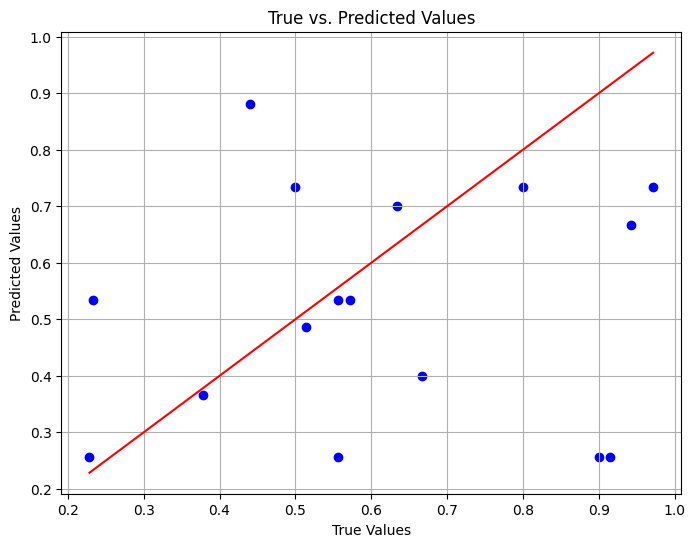

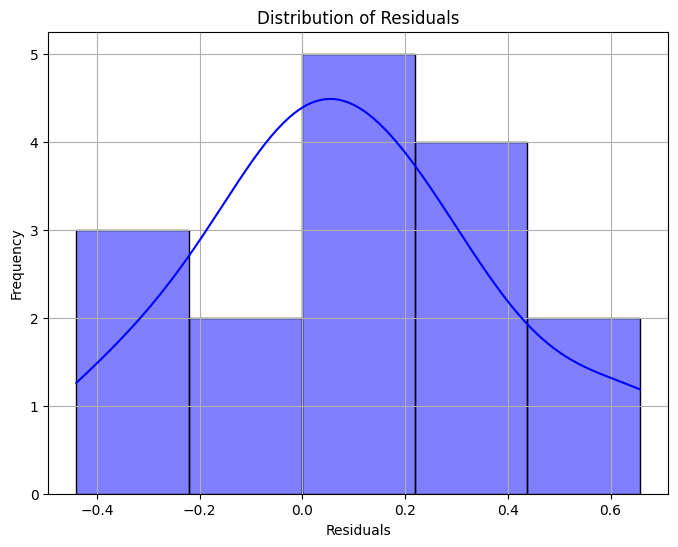

In [ ]:
from sklearn.tree import DecisionTreeRegressor

dtr = DecisionTreeRegressor()
dtr.fit(X_train, y_train)
y_pred = dtr.predict(X_test)
add_to_metrics(y_test,y_pred,"DTR")
visualize_results(y_test,y_pred)

In [ ]:
y_pred2 = dtr.predict(X_test2)
y_pred2

array([0.25714286])

# ***Random Forest***

Mean Absolute Error (MAE): 0.18639027777777784
Mean Squared Error (MSE): 0.05658879450050392
Root Mean Squared Error (RMSE): 0.2378839937879468
Mean Absolute Percentage Error (MAPE): 0.3493902299030493
R-squared (R²) Score: -0.056854299771475825


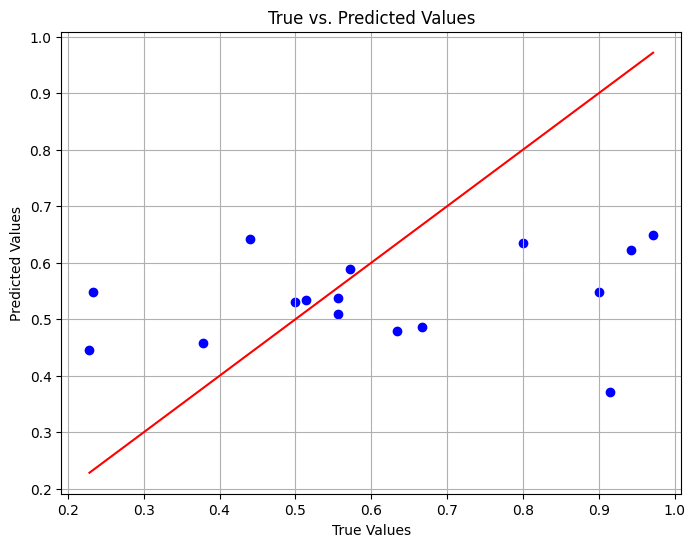

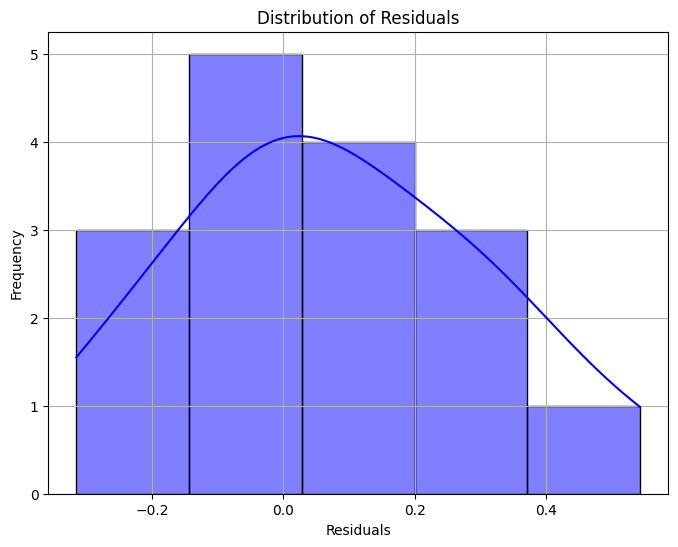

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rmf = RandomForestRegressor()
rmf.fit(X_train,y_train)
y_pred=rmf.predict(X_test)
add_to_metrics(y_test,y_pred,"RMF")
visualize_results(y_test,y_pred)

In [ ]:
y_pred2 = rmf.predict(X_test2)
y_pred2

array([0.37169841])

# ***Gradient Boosting***

Mean Absolute Error (MAE): 0.17761242300503954
Mean Squared Error (MSE): 0.055526897803049806
Root Mean Squared Error (RMSE): 0.23564146028033736
Mean Absolute Percentage Error (MAPE): 0.3215147722056393
R-squared (R²) Score: -0.037022280013438325


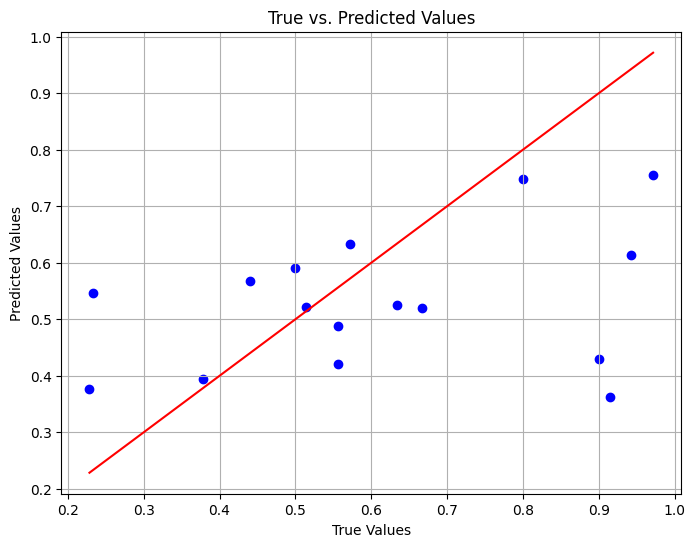

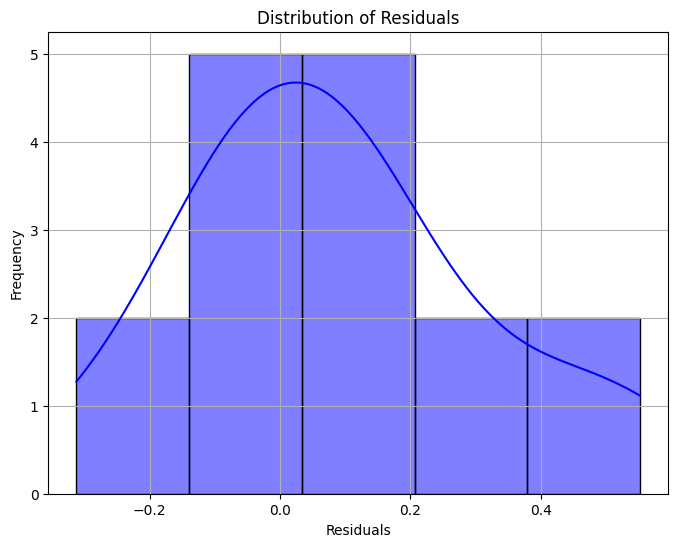

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gb_regressor = GradientBoostingRegressor(random_state=42)
gb_regressor.fit(X_train, y_train)
y_pred = gb_regressor.predict(X_test)
add_to_metrics(y_test,y_pred,"GB")
visualize_results(y_test,y_pred)

In [ ]:
y_pred2 = gb_regressor.predict(X_test2)
y_pred2

array([0.36226666])

# ***Extreme Gradient Boosting***

Mean Absolute Error (MAE): 0.20447430855934584
Mean Squared Error (MSE): 0.06385271679835189
Root Mean Squared Error (RMSE): 0.25269095116040835
Mean Absolute Percentage Error (MAPE): 0.3718436556724882
R-squared (R²) Score: -0.19251556595409713


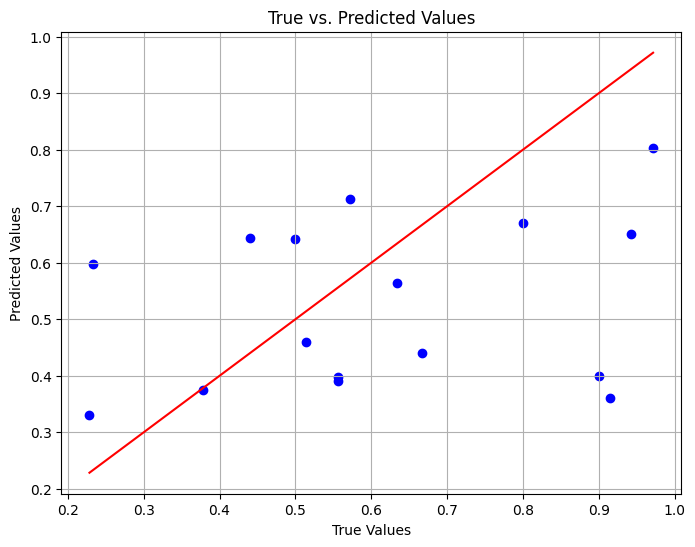

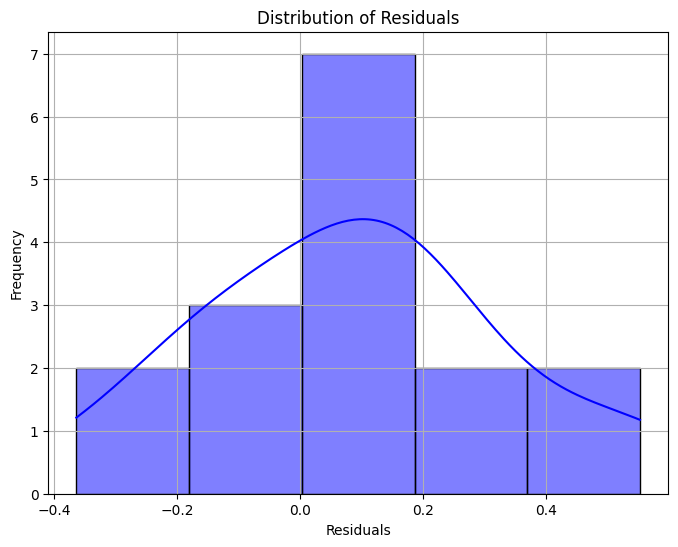

In [ ]:
import xgboost as xgb

xgb_regressor = xgb.XGBRegressor(random_state=42)
xgb_regressor.fit(X_train, y_train)
y_pred = xgb_regressor.predict(X_test)
add_to_metrics(y_test,y_pred,"XGB")
visualize_results(y_test,y_pred)

In [ ]:
y_pred2 = xgb_regressor.predict(X_test2)
y_pred2

array([0.3614774], dtype=float32)

# ***LightGBM***

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000051 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 217
[LightGBM] [Info] Number of data points in the train set: 47, number of used features: 20
[LightGBM] [Info] Start training from score 0.567977
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

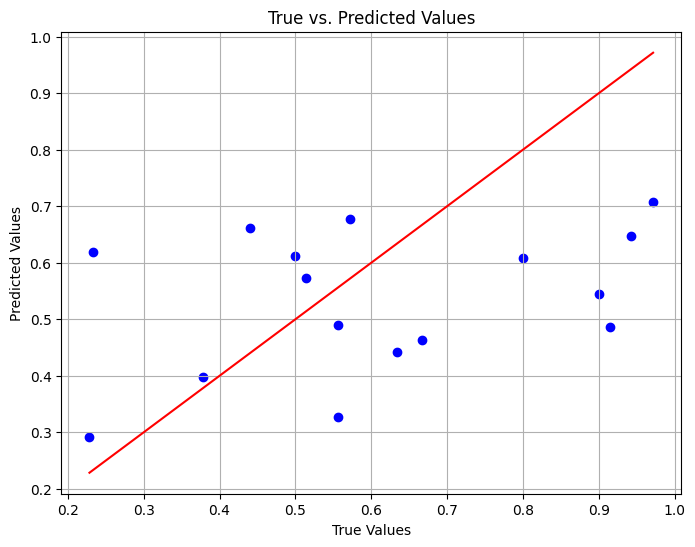

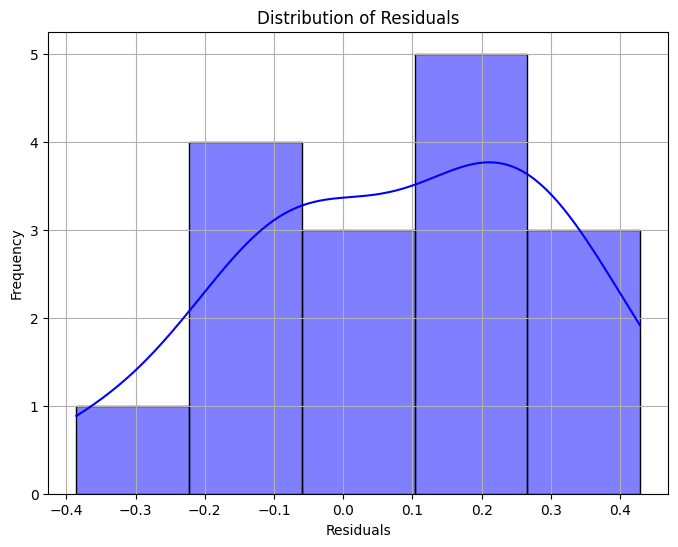

In [ ]:
import lightgbm as lgb

train_data = lgb.Dataset(X_train, label=y_train)
params = {'objective': 'regression', 'random_state': 42, 'learning_rate': 0.1, 'num_iterations': 1000}
lgb_regressor = lgb.train(params, train_data)
y_pred = lgb_regressor.predict(X_test)
add_to_metrics(y_test,y_pred,"LGB")
visualize_results(y_test,y_pred)

In [ ]:
y_pred2 = lgb_regressor.predict(X_test2)
y_pred2

array([0.48570237])

# ***SVR RBF Kernel***

Mean Absolute Error (MAE): 0.18918631791956853
Mean Squared Error (MSE): 0.05674945866958485
Root Mean Squared Error (RMSE): 0.2382214488025477
Mean Absolute Percentage Error (MAPE): 0.3938240780392559
R-squared (R²) Score: -0.059854869396808175


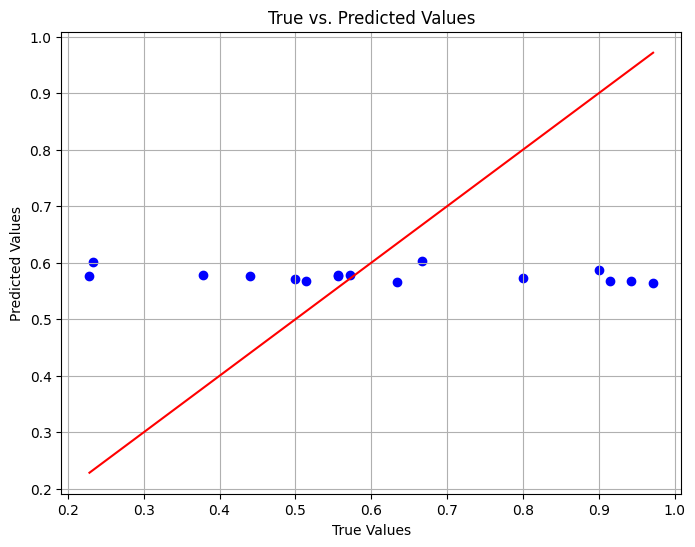

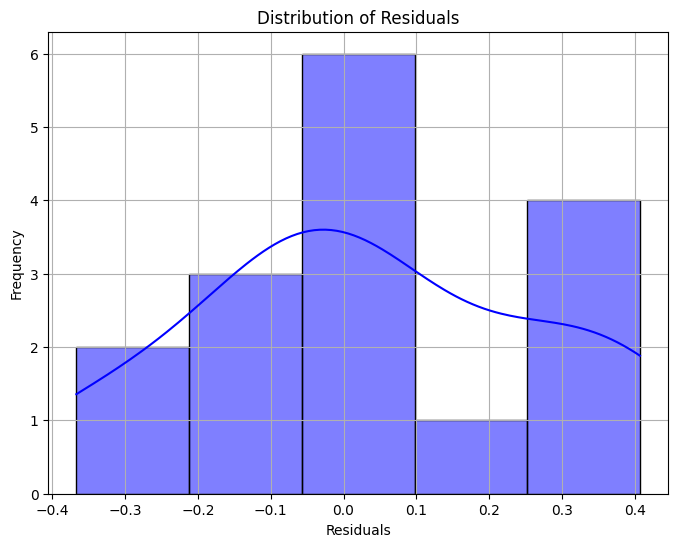

In [ ]:
from sklearn.svm import SVR

rbf_svr = SVR(kernel='rbf')
rbf_svr.fit(X_train, y_train)
y_pred = rbf_svr.predict(X_test)
add_to_metrics(y_test,y_pred,"SVM")
visualize_results(y_test,y_pred)

In [ ]:
y_pred2 = rbf_svr.predict(X_test2)
y_pred2

array([0.56786212])

# ***Ridge Regression***

Mean Absolute Error (MAE): 0.1525803851156693
Mean Squared Error (MSE): 0.04461278284898914
Root Mean Squared Error (RMSE): 0.21121738292335018
Mean Absolute Percentage Error (MAPE): 0.23618485750506435
R-squared (R²) Score: 0.1668101115264885


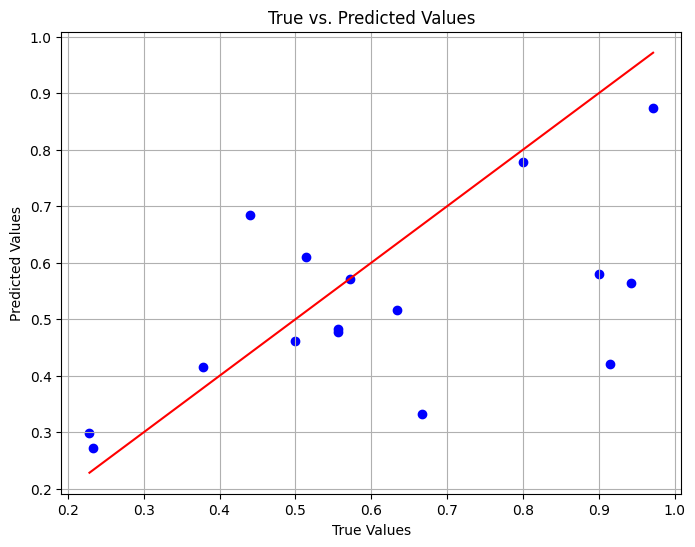

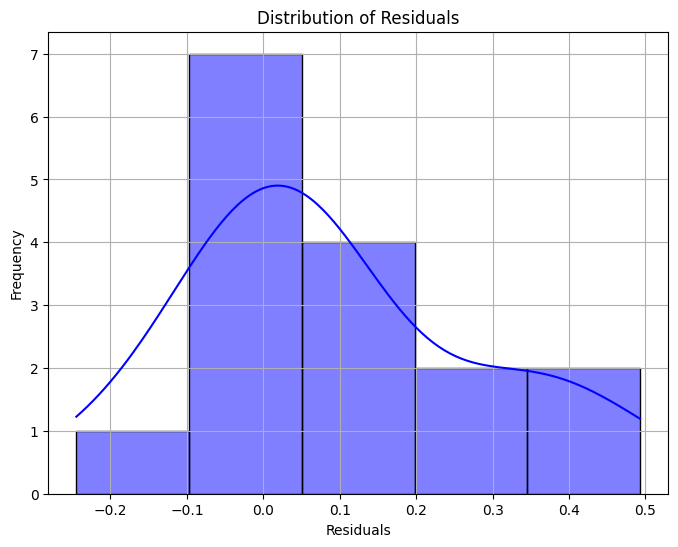

In [ ]:
from sklearn.linear_model import Ridge

alpha = 1.0
ridge_reg = Ridge(alpha=alpha)
ridge_reg.fit(X_train, y_train)
y_pred = ridge_reg.predict(X_test)
add_to_metrics(y_test,y_pred,"Ridge")
visualize_results(y_test,y_pred)

In [ ]:
y_pred2 = ridge_reg.predict(X_test2)
y_pred2

array([0.42150364])

# ***Lasso Regression***

Mean Absolute Error (MAE): 0.192208798388257
Mean Squared Error (MSE): 0.05921191889683738
Root Mean Squared Error (RMSE): 0.24333499316135643
Mean Absolute Percentage Error (MAPE): 0.3826449108784853
R-squared (R²) Score: -0.10584386248562372


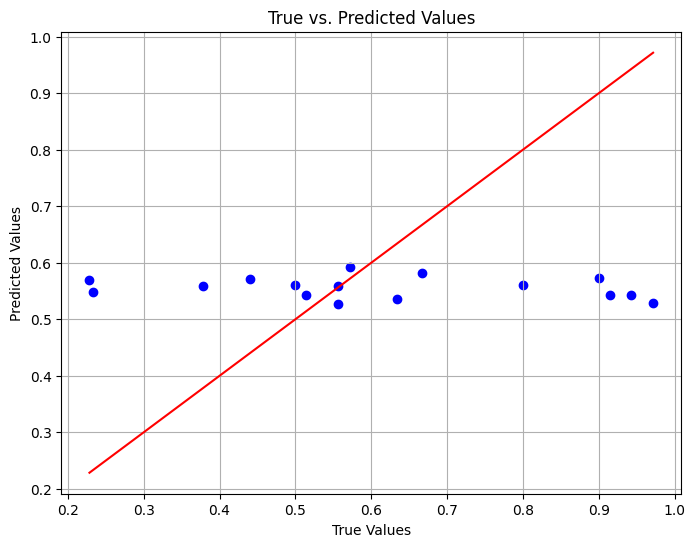

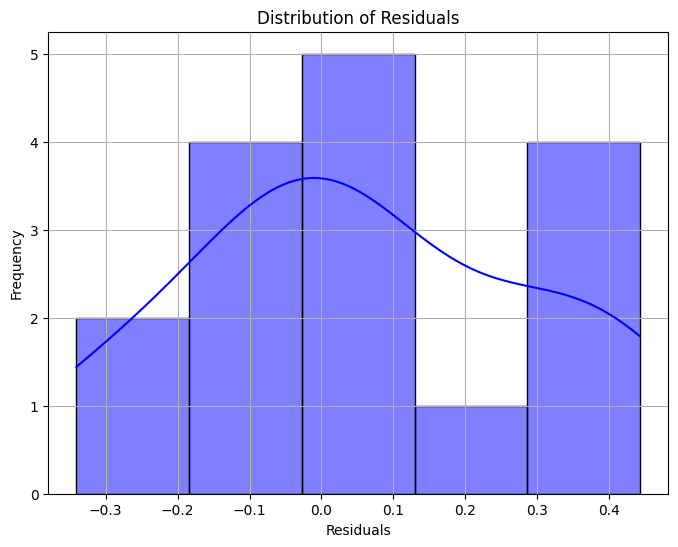

In [ ]:
from sklearn.linear_model import Lasso

alpha = 0.1
lasso_reg = Lasso(alpha=alpha)
lasso_reg.fit(X_train_orig, y_train_orig)
y_pred = lasso_reg.predict(X_test_orig)
add_to_metrics(y_test_orig,y_pred,"Lasso")
visualize_results(y_test_orig,y_pred)

In [ ]:
y_pred2 = lasso_reg.predict(X_test2_orig)
y_pred2

array([0.54226195])

In [ ]:
# import numpy as np
# from sklearn.linear_model import Lasso

# # Create a Lasso model
# model = Lasso()

# # Fit the model
# model.fit(X_train_orig, y_train_orig)

# # Access coefficients
# coefficients = model.coef_

# # Print features and their coefficients
# print("Features:", features_orig)
# print("Coefficients:", coefficients)

# # Identify features with zero coefficients (selected features)
# selected_features = np.where(coefficients == 0)[0]

# # Print selected features
# print("Selected features:", [features_orig[i] for i in selected_features])

# # Analyze non-zero coefficients for relative importance
# non_zero_features = np.where(coefficients != 0)[0]
# importance = np.abs(coefficients[non_zero_features])

# # Print features and their relative importance
# print("Feature importance (example):")
# for i, feature in enumerate(non_zero_features):
#     print(f"{features_orig[i]}: {importance[i]}")


# ***ANN***

In [ ]:
# import tensorflow as tf
# from tensorflow import keras

# model = keras.Sequential([
#   keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
#   keras.layers.Dense(64, activation='relu'),
#   keras.layers.Dense(1)
# ])
# model.compile(loss='mse', optimizer='adam')
# model.fit(X_train, y_train, epochs=10, batch_size=32)
# y_pred = model.predict(X_test)
# y_pred = np.squeeze(y_pred)
# add_to_metrics(y_test,y_pred,"ANN")
# visualize_results(y_test,y_pred)

In [ ]:
# y_pred2 = model.predict(X_test2)
# y_pred2 = np.squeeze(y_pred2)
# y_pred2

# ***Comparing model performances***

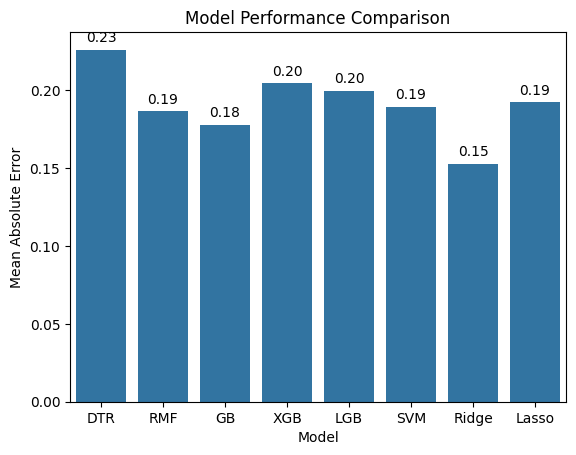

In [ ]:
axis = sns.barplot(x = 'Name', y = 'mae', data = pd.DataFrame({'Name': names, 'mae': mae}) )
axis.set(title='Model Performance Comparison',xlabel='Model', ylabel='Mean Absolute Error')
for p in axis.patches:
    height = p.get_height()
    axis.text(p.get_x() + p.get_width()/2, height + 0.005, '{:1.2f}'.format(height), ha="center")

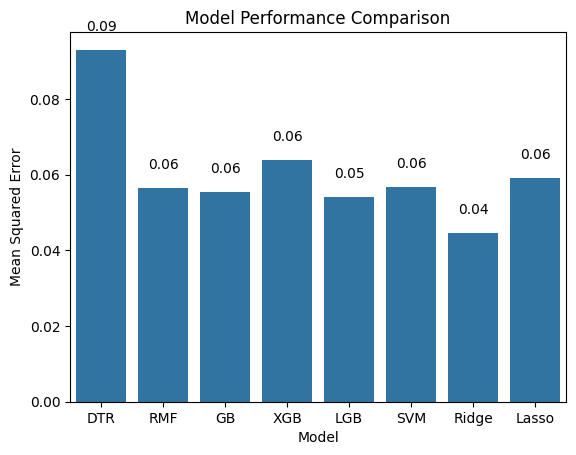

In [ ]:
axis = sns.barplot(x = 'Name', y = 'mse', data = pd.DataFrame({'Name': names, 'mse': mse}) )
axis.set(title='Model Performance Comparison',xlabel='Model', ylabel='Mean Squared Error')
for p in axis.patches:
    height = p.get_height()
    axis.text(p.get_x() + p.get_width()/2, height + 0.005, '{:1.2f}'.format(height), ha="center")

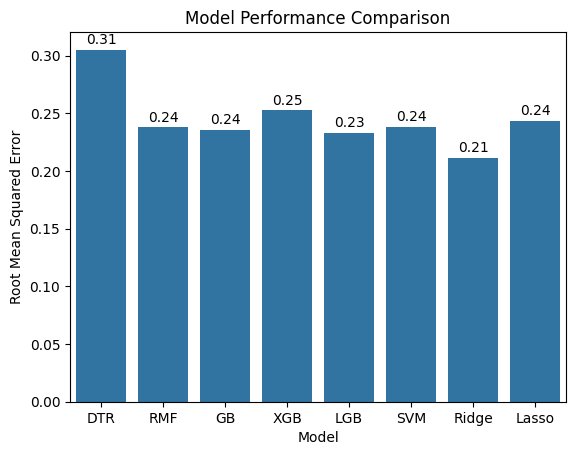

In [ ]:
axis = sns.barplot(x = 'Name', y = 'rmse', data = pd.DataFrame({'Name': names, 'rmse': rmse}) )
axis.set(title='Model Performance Comparison',xlabel='Model', ylabel='Root Mean Squared Error')
for p in axis.patches:
    height = p.get_height()
    axis.text(p.get_x() + p.get_width()/2, height + 0.005, '{:1.2f}'.format(height), ha="center")

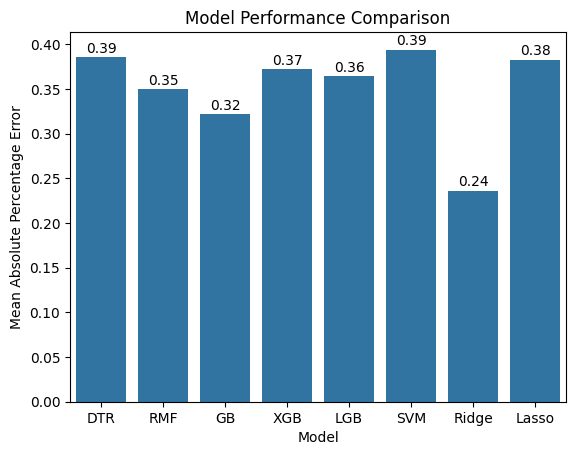

In [ ]:
axis = sns.barplot(x = 'Name', y = 'mape', data = pd.DataFrame({'Name': names, 'mape': mape}) )
axis.set(title='Model Performance Comparison',xlabel='Model', ylabel='Mean Absolute Percentage Error')
for p in axis.patches:
    height = p.get_height()
    axis.text(p.get_x() + p.get_width()/2, height + 0.005, '{:1.2f}'.format(height), ha="center")

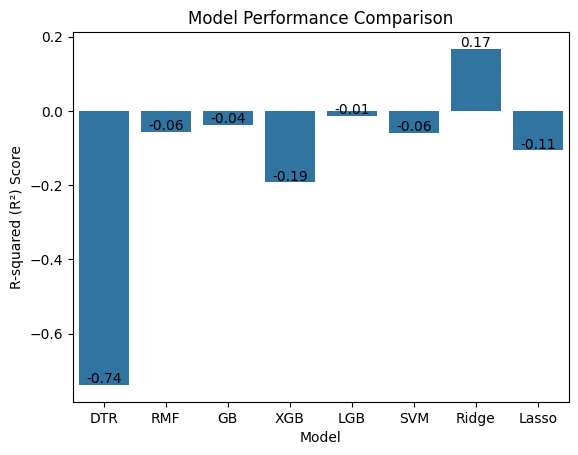

In [ ]:
axis = sns.barplot(x = 'Name', y = 'r2', data = pd.DataFrame({'Name': names, 'r2': r2}) )
axis.set(title='Model Performance Comparison',xlabel='Model', ylabel='R-squared (R²) Score')
for p in axis.patches:
    height = p.get_height()
    axis.text(p.get_x() + p.get_width()/2, height + 0.005, '{:1.2f}'.format(height), ha="center")

# ***Hyper Tuning Ridge & Lasso***

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.linear_model import Ridge, Lasso
# from sklearn.model_selection import RandomizedSearchCV

# # Define parameter distributions for randomized search
# param_dist = {
#     "alpha": np.logspace(-3, 2, 50)  # Explore lambda values from 0.001 to 100 on a log scale
# }

# # Define randomized search objects
# ridge_search = RandomizedSearchCV(Ridge(), param_dist, n_iter=100, cv=3)  # 100 random trials, 5-fold CV
# lasso_search = RandomizedSearchCV(Lasso(), param_dist, n_iter=100, cv=3)  # Same settings

# # Perform randomized search for Ridge and Lasso
# ridge_search.fit(X_train, y_train)
# lasso_search.fit(X_train_orig, y_train_orig)

# # Best models for Ridge and Lasso
# best_ridge = ridge_search.best_estimator_
# best_lasso = lasso_search.best_estimator_

# # Best parameters for Ridge and Lasso
# best_lambda_ridge = ridge_search.best_params_["alpha"]
# best_lambda_lasso = lasso_search.best_params_["alpha"]

# # Function to get coefficients for different lambda values
# def get_coef_path(model, lambda_range):
#     coef_path = []
#     for lambd in lambda_range:
#         model.set_params(alpha=lambd)
#         model.fit(X_train, y_train)
#         coef_path.append(model.coef_)
#     return np.array(coef_path)

# # Get regularization paths for Ridge and Lasso
# ridge_coef_path = get_coef_path(Ridge(), lambda_range=np.logspace(-3, 2, 50))
# lasso_coef_path = get_coef_path(Lasso(), lambda_range=np.logspace(-3, 2, 50))

# # Plot the regularization paths
# plt.figure(figsize=(20, 6))
#  # Assuming the original feature names

# # Handle potential index out-of-bounds issue
# max_features = min(len(ridge_coef_path[0]), len(lasso_coef_path[0]), len(features_orig))
# features_to_plot = features_orig[:max_features]  # Truncate features if necessary

# for i, feature in enumerate(features_to_plot):
#     plt.plot(np.logspace(-3, 2, 50), ridge_coef_path[:, i], label=f"Ridge - {feature}")
#     plt.plot(np.logspace(-3, 2, 50), lasso_coef_path[:, i], label=f"Lasso - {feature}")

# plt.xlabel("Lambda (alpha)")
# plt.ylabel("Coefficient value")
# plt.title("Regularization Path for Ridge and Lasso")
# plt.legend()
# plt.semilogx()  # Use semilogx for better visualization on a log scale
# plt.grid(True)
# plt.show()

# # Print best lambda values
# print(f"Best lambda for Ridge: {best_lambda_ridge}")
# print(f"Best lambda for Lasso: {best_lambda_lasso}")

# # Use the best model for prediction
# print("Best Ridge Model Prediction:")
# y_pred = best_ridge.predict(X_test)
# add_to_metrics(y_test,y_pred,"HRidge")
# visualize_results(y_test,y_pred)

# print("Best Lasso Model Prediction:")
# y_pred = best_lasso.predict(X_test_orig)
# add_to_metrics(y_test_orig,y_pred,"HLasso")
# visualize_results(y_test_orig,y_pred)

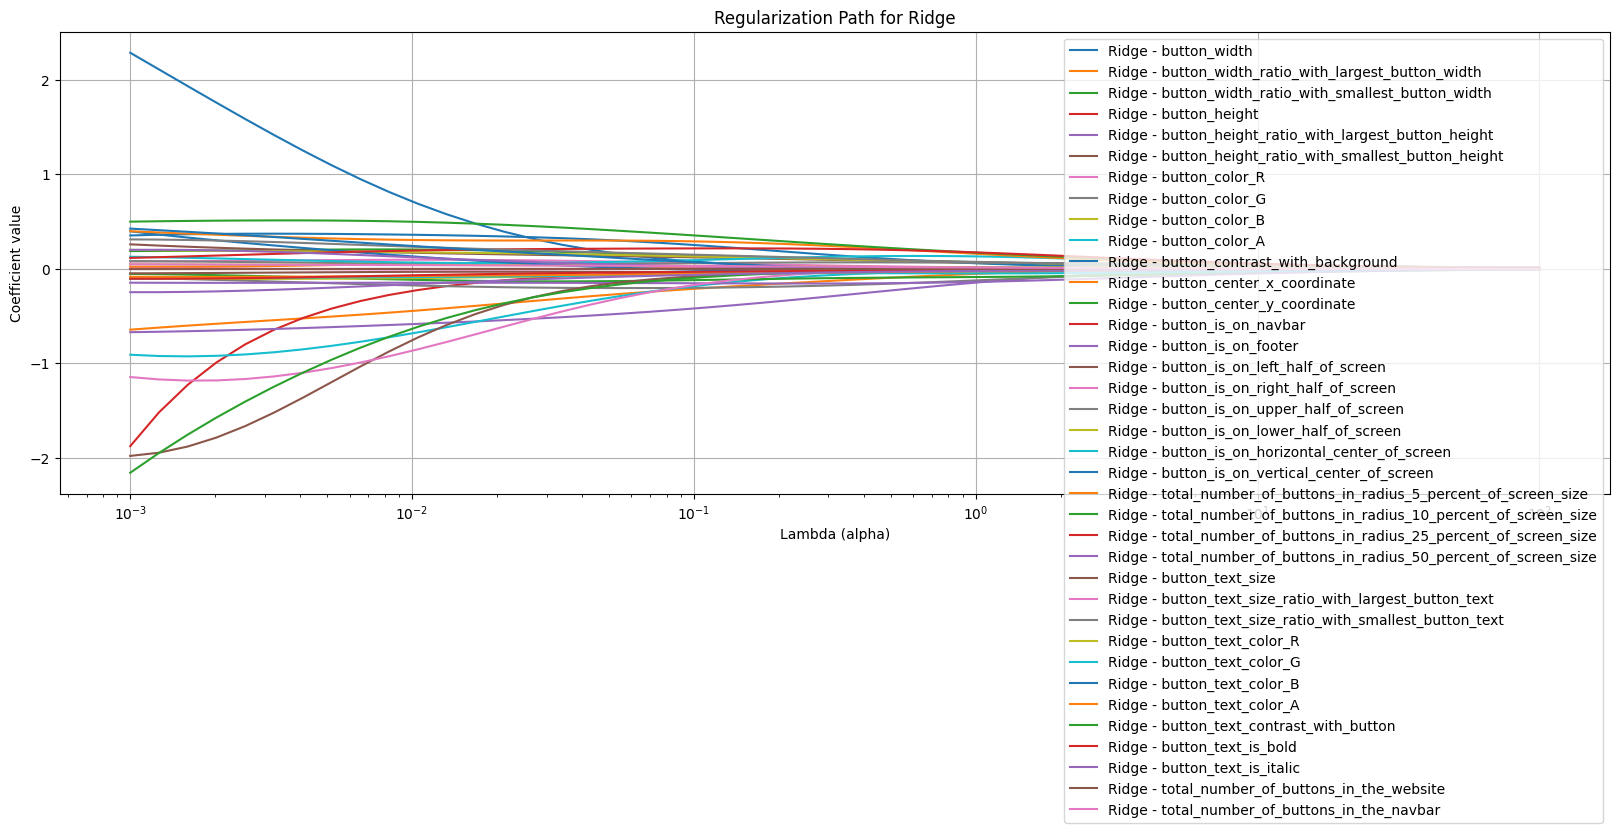

Best lambda for Ridge: 4.714866363457395
Best Ridge Model Prediction:
Mean Absolute Error (MAE): 0.16537830291698452
Mean Squared Error (MSE): 0.042486560543993315
Root Mean Squared Error (RMSE): 0.20612268323499314
Mean Absolute Percentage Error (MAPE): 0.2896807762264211
R-squared (R²) Score: 0.20651951345207376


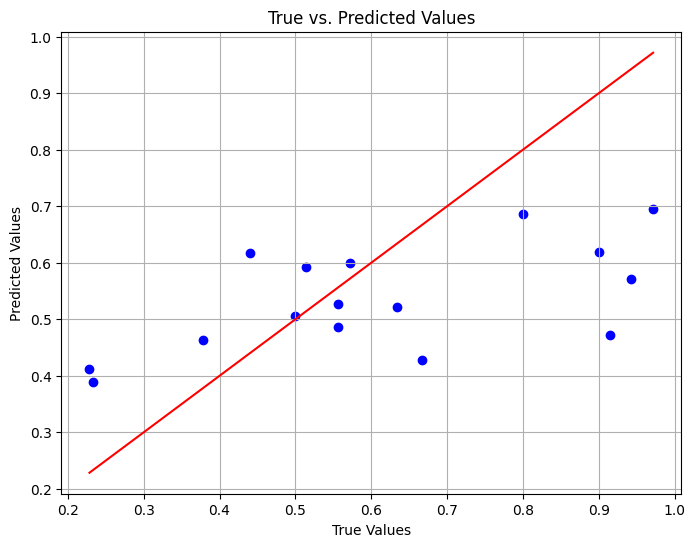

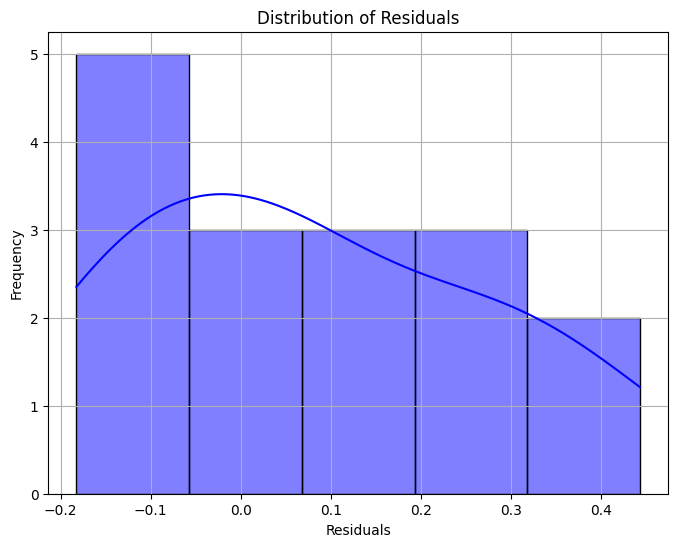

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.model_selection import RandomizedSearchCV

# Define parameter distributions for randomized search
param_dist = {
    "alpha": np.logspace(-3, 2, 50)  # Explore lambda values from 0.001 to 100 on a log scale
}

# Define randomized search objects
ridge_search = RandomizedSearchCV(Ridge(), param_dist, n_iter=100, cv=3)

# Perform randomized search for Ridge
ridge_search.fit(X_train, y_train)

# Best models for Ridge
best_ridge = ridge_search.best_estimator_

# Best parameters for Ridge
best_lambda_ridge = ridge_search.best_params_["alpha"]

# Function to get coefficients for different lambda values
def get_coef_path(model, lambda_range):
    coef_path = []
    for lambd in lambda_range:
        model.set_params(alpha=lambd)
        model.fit(X_train, y_train)
        coef_path.append(model.coef_)
    return np.array(coef_path)

# Get regularization paths for Ridge
ridge_coef_path = get_coef_path(Ridge(), lambda_range=np.logspace(-3, 2, 50))

# Plot the regularization paths
plt.figure(figsize=(20, 6))
 # Assuming the original feature names

# Handle potential index out-of-bounds issue
max_features = min(len(ridge_coef_path[0]), len(features_orig))
features_to_plot = features_orig[:max_features]  # Truncate features if necessary

for i, feature in enumerate(features_to_plot):
    plt.plot(np.logspace(-3, 2, 50), ridge_coef_path[:, i], label=f"Ridge - {feature}")

plt.xlabel("Lambda (alpha)")
plt.ylabel("Coefficient value")
plt.title("Regularization Path for Ridge")
plt.legend()
plt.semilogx()  # Use semilogx for better visualization on a log scale
plt.grid(True)
plt.show()

# Print best lambda values
print(f"Best lambda for Ridge: {best_lambda_ridge}")

# Use the best model for prediction
print("Best Ridge Model Prediction:")
y_pred = best_ridge.predict(X_test)
add_to_metrics(y_test,y_pred,"HRidge")
visualize_results(y_test,y_pred)

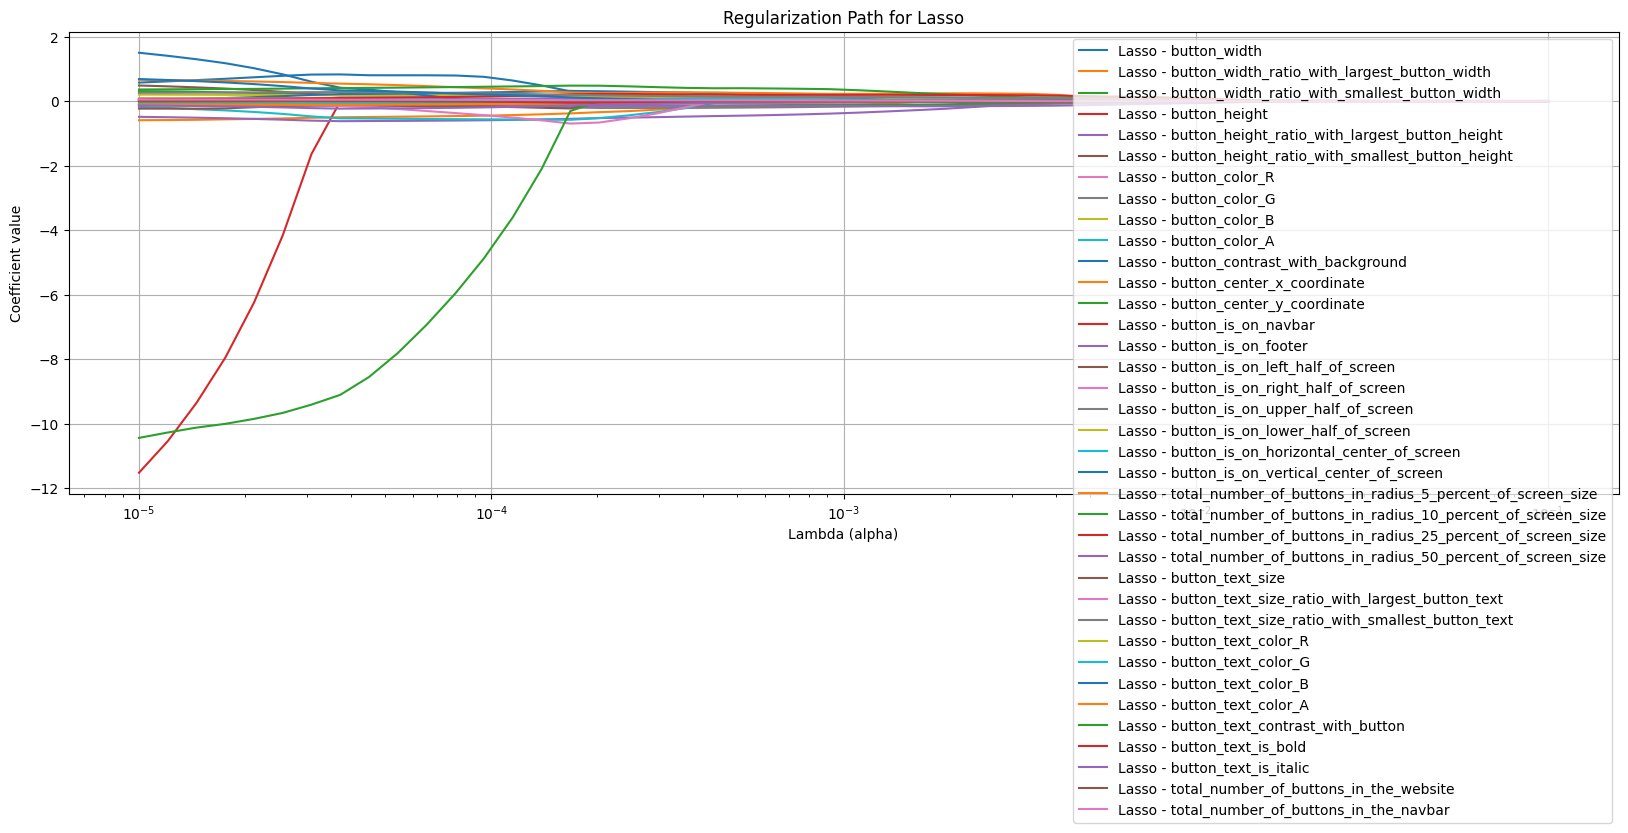

Best lambda for Lasso: 0.004941713361323833
Best Lasso Model Prediction:
Mean Absolute Error (MAE): 0.16395393840179903
Mean Squared Error (MSE): 0.0419913530078396
Root Mean Squared Error (RMSE): 0.20491791773253895
Mean Absolute Percentage Error (MAPE): 0.27102218521748866
R-squared (R²) Score: 0.2157680266689197


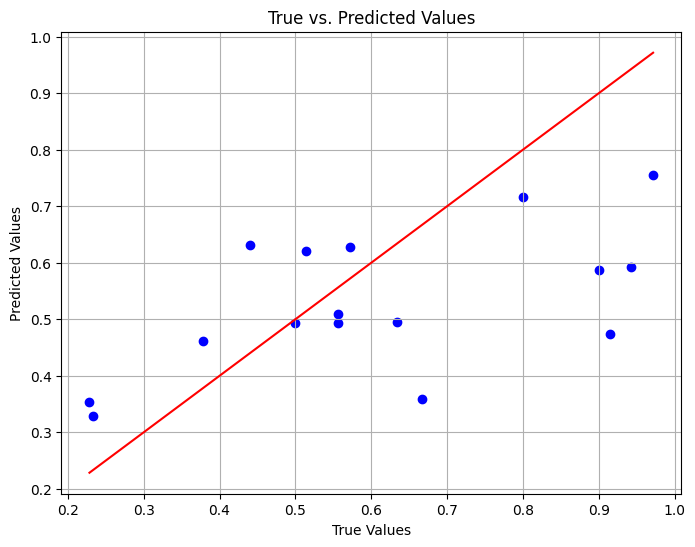

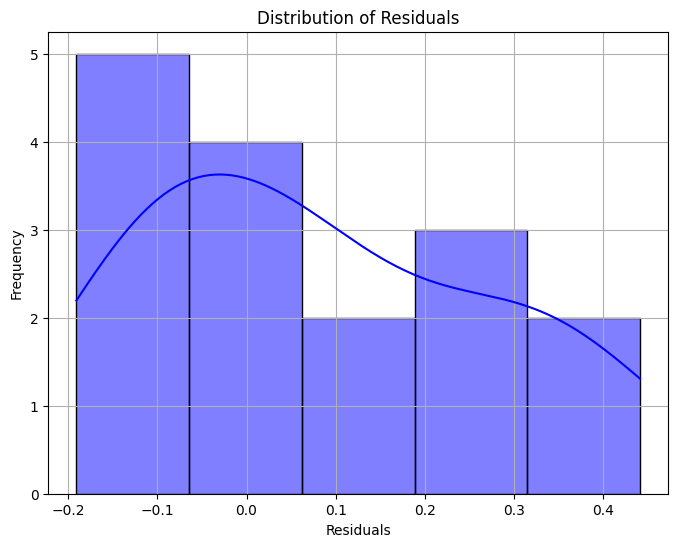

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.model_selection import RandomizedSearchCV

# Define parameter distributions for randomized search
param_dist = {
    "alpha": np.logspace(-5, -1, 50)  # Explore lambda values from 0.001 to 100 on a log scale
}

# Define randomized search objects
lasso_search = RandomizedSearchCV(Lasso(), param_dist, n_iter=100, cv=3)

# Perform randomized search for Lasso
lasso_search.fit(X_train_orig, y_train_orig)

# Best models for Lasso
best_lasso = lasso_search.best_estimator_

# Best parameters for Lasso
best_lambda_lasso = lasso_search.best_params_["alpha"]

# Function to get coefficients for different lambda values
def get_coef_path(model, lambda_range):
    coef_path = []
    for lambd in lambda_range:
        model.set_params(alpha=lambd)
        model.fit(X_train, y_train)
        coef_path.append(model.coef_)
    return np.array(coef_path)

# Get regularization paths for Lasso
lasso_coef_path = get_coef_path(Lasso(), lambda_range=np.logspace(-5, -1, 50))

# Plot the regularization paths
plt.figure(figsize=(20, 6))
 # Assuming the original feature names

# Handle potential index out-of-bounds issue
max_features = min(len(lasso_coef_path[0]), len(features_orig))
features_to_plot = features_orig[:max_features]  # Truncate features if necessary

for i, feature in enumerate(features_to_plot):
    plt.plot(np.logspace(-5, -1, 50), lasso_coef_path[:, i], label=f"Lasso - {feature}")

plt.xlabel("Lambda (alpha)")
plt.ylabel("Coefficient value")
plt.title("Regularization Path for Lasso")
plt.legend()
plt.semilogx()  # Use semilogx for better visualization on a log scale
plt.grid(True)
plt.show()

# Print best lambda values
print(f"Best lambda for Lasso: {best_lambda_lasso}")

print("Best Lasso Model Prediction:")
y_pred = best_lasso.predict(X_test_orig)
add_to_metrics(y_test_orig,y_pred,"HLasso")
visualize_results(y_test_orig,y_pred)

# ***Downloading PKL Files***

In [ ]:
with open('features.txt', 'w') as file:
    for feature in features:
        file.write(feature + '\n')
files.download('features.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# with open('scaler.pkl', 'wb') as file:
#     pickle.dump(scaler, file)
# files.download("scaler.pkl")

In [ ]:
with open('order_model.pkl', 'wb') as file:
    pickle.dump(best_ridge, file)
files.download("order_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# If ANN is chosen
# with open('le1.pkl', 'wb') as file:
#     pickle.dump(le1, file)
# files.download("le1.pkl")

# ***PLAY SOUND ONCE ALL THE CODES ARE EXECUTED***

In [ ]:
from IPython.display import HTML
# Display the HTML element
display(HTML(f"""<audio controls autoplay loop><source src='http://codeskulptor-demos.commondatastorage.googleapis.com/descent/gotitem.mp3' type="audio/mpeg"></audio>"""))